In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import tensorflow as tf

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.kernel_approximation import Nystroem
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, roc_auc_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler

from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

folder_path = '/content/drive/MyDrive/Colab Notebooks/cybersec_ml_mgr/'

try:
    X_train = pd.read_csv(folder_path + 'X_train.csv')
    X_test = pd.read_csv(folder_path + 'X_test.csv')
    y_train = pd.read_csv(folder_path + 'y_train.csv')
    y_test = pd.read_csv(folder_path + 'y_test.csv')

    y_train = y_train.values.ravel()
    y_test = y_test.values.ravel()
except Exception as e:
    print(f"Problem z ładowaniem plików: {e}")

In [3]:
def zapisz_macierz_pomylek(cm, tytul="Macierz pomyłek", nazwa_pliku="confusion_matrix.png"):
    katalog_docelowy = "/content/drive/MyDrive/Colab Notebooks/cybersec_ml_mgr/confusion_matrix/"
    os.makedirs(katalog_docelowy, exist_ok=True)
    pelna_sciezka = os.path.join(katalog_docelowy, nazwa_pliku)

    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Calibri', 'Arial', 'Liberation Sans', 'DejaVu Sans']
    plt.figure(figsize=(6, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ruch bezpieczny', 'Atak'],
                yticklabels=['Ruch bezpieczny', 'Atak'], square=True, vmin=0, vmax=1100, cbar=False,
                linewidths=1, linecolor='white', annot_kws={"size": 12})

    plt.title(tytul, fontsize=15, pad=15, weight='bold')
    plt.ylabel('Rzeczywista klasa', fontsize=14)
    plt.xlabel('Predykcja modelu', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.tight_layout()
    plt.savefig(pelna_sciezka, dpi=300, bbox_inches='tight', transparent=False, facecolor='white')
    plt.show()
    plt.close()

def zapisz_raport_klasyfikacji(y_true, y_pred, nazwa_pliku="raport_klasyfikacji.xlsx"):
    katalog_docelowy = "/content/drive/MyDrive/Colab Notebooks/cybersec_ml_mgr/raporty/"
    os.makedirs(katalog_docelowy, exist_ok=True)
    pelna_sciezka = os.path.join(katalog_docelowy, nazwa_pliku)

    raport_slownik = classification_report(y_true, y_pred, output_dict=True)
    df_raport = pd.DataFrame(raport_slownik).transpose().round(2)

    if 'support' in df_raport.columns:
        df_raport['support'] = df_raport['support'].astype(int)

    df_raport.to_excel(pelna_sciezka, index=True)

def zapisz_krzywa_roc(y_true, y_scores, tytul="Krzywa ROC", nazwa_pliku="roc_curve.png"):
    katalog_docelowy = "/content/drive/MyDrive/Colab Notebooks/cybersec_ml_mgr/roc_curves/"
    os.makedirs(katalog_docelowy, exist_ok=True)
    pelna_sciezka = os.path.join(katalog_docelowy, nazwa_pliku)

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    auc_wartosc = roc_auc_score(y_true, y_scores)

    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Calibri', 'Arial', 'Liberation Sans', 'DejaVu Sans']
    plt.figure(figsize=(6, 5))

    plt.plot(fpr, tpr, color='#1558d6', linewidth=2, label=f'Krzywa modelu (AUC = {auc_wartosc:.4f})')
    plt.plot([0, 1], [0, 1], color='#eaa937', linestyle='--', linewidth=2, label='Klasyfikator losowy (AUC = 0.50)')

    plt.title(tytul, fontsize=16, pad=20, weight='bold')
    plt.xlabel('Odsetek fałszywych alarmów (FPR)', fontsize=13)
    plt.ylabel('Czułość (Recall / TPR)', fontsize=13)
    plt.legend(loc='lower right', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.savefig(pelna_sciezka, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close()

    return auc_wartosc

def calculate_fpr(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return fp / (fp + tn) if (fp + tn) > 0 else 0.0

Accuracy: 0.8863
FPR: 0.0019
              precision    recall  f1-score   support

           0      0.830     0.998     0.907      1055
           1      0.997     0.748     0.855       853

    accuracy                          0.886      1908
   macro avg      0.914     0.873     0.881      1908
weighted avg      0.905     0.886     0.883      1908



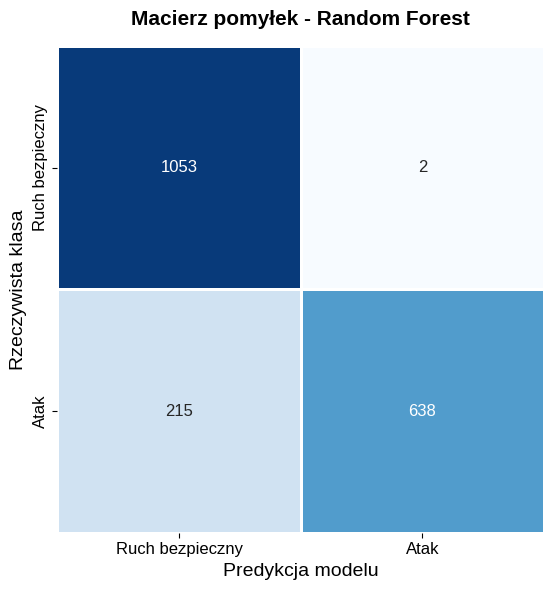

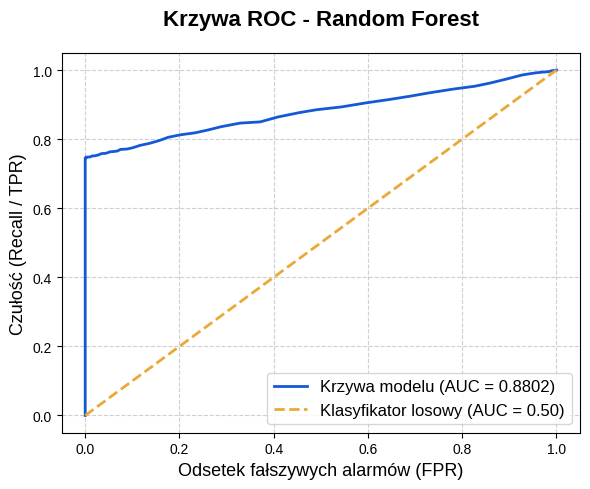

np.float64(0.880218687320469)

In [4]:
# ============================================================
# 1. Implementacja i trenowanie modelu Random Forest
# (Domyślne parametry)
# ============================================================
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_scores_rf = rf_model.predict_proba(X_test)[:, 1]

cm_rf = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm_rf.ravel()
fpr_rf = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"FPR: {fpr_rf:.4f}")
print(classification_report(y_test, y_pred_rf, digits=3))

zapisz_macierz_pomylek(cm_rf, 'Macierz pomyłek - Random Forest', 'confusion_matrix_random_forest.png')
zapisz_raport_klasyfikacji(y_test, y_pred_rf, 'raport_random_forest.xlsx')
zapisz_krzywa_roc(y_test, y_scores_rf, 'Krzywa ROC - Random Forest', 'roc_random_forest.png')

Accuracy: 0.8391
FPR: 0.1090
              precision    recall  f1-score   support

           0      0.830     0.891     0.860      1055
           1      0.852     0.775     0.812       853

    accuracy                          0.839      1908
   macro avg      0.841     0.833     0.836      1908
weighted avg      0.840     0.839     0.838      1908



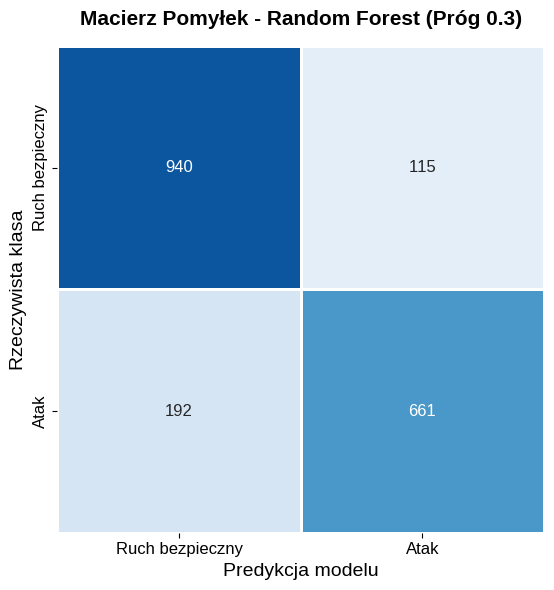

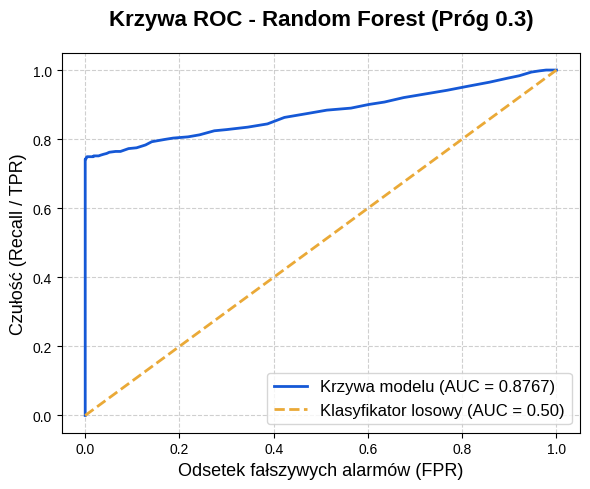

np.float64(0.8766700188351123)

In [5]:
# ============================================================
# 1.1. Implementacja i trenowanie modelu Random Forest
# (Class Weights, próg 0.3)
# ============================================================
rf_optimized = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf_optimized.fit(X_train, y_train)

y_pred_proba = rf_optimized.predict_proba(X_test)[:, 1]
custom_threshold = 0.30
y_pred_rf_opt = (y_pred_proba >= custom_threshold).astype(int)

cm_rf_opt = confusion_matrix(y_test, y_pred_rf_opt)
tn, fp, fn, tp = cm_rf_opt.ravel()
fpr_rf_opt = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_opt):.4f}")
print(f"FPR: {fpr_rf_opt:.4f}")
print(classification_report(y_test, y_pred_rf_opt, digits=3))

zapisz_macierz_pomylek(cm_rf_opt, f'Macierz Pomyłek - Random Forest (Próg {custom_threshold})', 'confusion_matrix_rf_opt.png')
zapisz_raport_klasyfikacji(y_test, y_pred_rf_opt, 'raport_random_forest_opt.xlsx')
zapisz_krzywa_roc(y_test, y_pred_proba, f'Krzywa ROC - Random Forest (Próg {custom_threshold})', 'roc_random_forest_opt.png')

Accuracy: 0.8800
FPR: 0.0227
              precision    recall  f1-score   support

           0      0.834     0.977     0.900      1055
           1      0.964     0.760     0.850       853

    accuracy                          0.880      1908
   macro avg      0.899     0.868     0.875      1908
weighted avg      0.892     0.880     0.878      1908



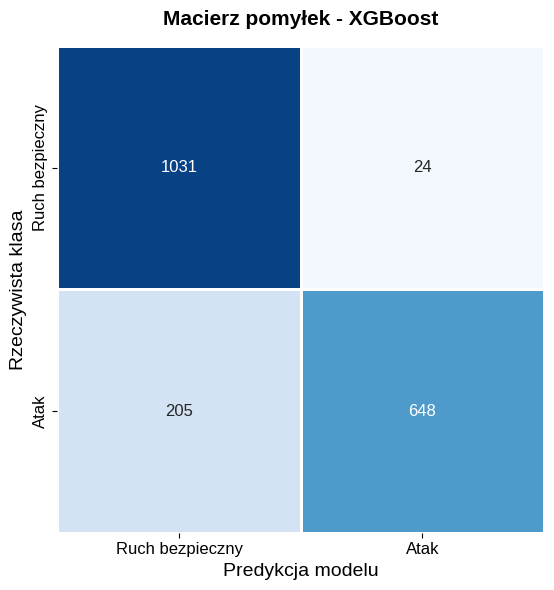

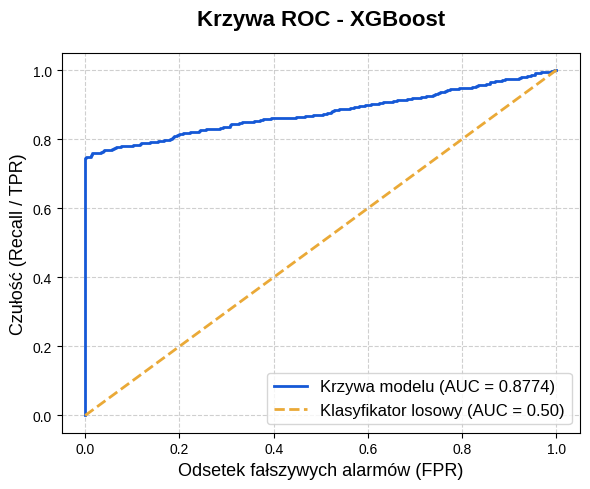

In [6]:
# ============================================================
# 2. Implementacja i trenowanie modelu XGBoost
# (Domyślne parametry)
# ============================================================
stosunek_klas = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42, scale_pos_weight=stosunek_klas, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_scores_xgb = xgb_model.predict_proba(X_test)[:, 1]

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm_xgb.ravel()
fpr_xgb = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"FPR: {fpr_xgb:.4f}")
print(classification_report(y_test, y_pred_xgb, digits=3))

zapisz_macierz_pomylek(cm_xgb, 'Macierz pomyłek - XGBoost', 'confusion_matrix_xgboost.png')
zapisz_raport_klasyfikacji(y_test, y_pred_xgb, 'raport_xgboost.xlsx')
zapisz_krzywa_roc(y_test, y_scores_xgb, 'Krzywa ROC - XGBoost', 'roc_xgboost.png')

katalog_wykresow = "/content/drive/MyDrive/Colab Notebooks/cybersec_ml_mgr/wykresy/"
os.makedirs(katalog_wykresow, exist_ok=True)

importance_gain = xgb_model.get_booster().get_score(importance_type='gain')
sorted_gain = dict(sorted(importance_gain.items(), key=lambda item: item[1], reverse=False))
top_features_gain = list(sorted_gain.keys())[-10:]
top_values_gain = list(sorted_gain.values())[-10:]

plt.figure(figsize=(10, 6))
bars = plt.barh(top_features_gain, top_values_gain, color='#e58d4a', edgecolor='black', linewidth=0.5)
for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f' {bar.get_width():.2f}', va='center', ha='left', fontsize=10)

plt.title('Ważność Cech - XGBoost (Metoda: Zysk Informacyjny)', fontsize=15, pad=15, weight='bold')
plt.xlabel('Średni zysk informacyjny', fontsize=12)
plt.ylabel('Cecha sieciowa', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(katalog_wykresow, 'xgb_importance_gain.png'), dpi=300, bbox_inches='tight', transparent=False, facecolor='white')
plt.close()

importance_weight = xgb_model.get_booster().get_score(importance_type='weight')
sorted_weight = dict(sorted(importance_weight.items(), key=lambda item: item[1], reverse=False))
top_features_weight = list(sorted_weight.keys())[-10:]
top_values_weight = list(sorted_weight.values())[-10:]

plt.figure(figsize=(10, 6))
bars = plt.barh(top_features_weight, top_values_weight, color='#2c7bb6', edgecolor='black', linewidth=0.5)
for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f' {int(bar.get_width())}', va='center', ha='left', fontsize=10)

plt.title('Ważność Cech - XGBoost (Metoda: Waga)', fontsize=15, pad=15, weight='bold')
plt.xlabel('Liczba użyć cechy w węzłach drzew decyzyjnych', fontsize=12)
plt.ylabel('Cecha sieciowa', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(katalog_wykresow, 'xgb_importance_weight.png'), dpi=300, bbox_inches='tight', transparent=False, facecolor='white')
plt.close()

Accuracy: 0.8863
FPR: 0.0000
              precision    recall  f1-score   support

           0      0.829     1.000     0.907      1055
           1      1.000     0.746     0.854       853

    accuracy                          0.886      1908
   macro avg      0.915     0.873     0.881      1908
weighted avg      0.906     0.886     0.883      1908



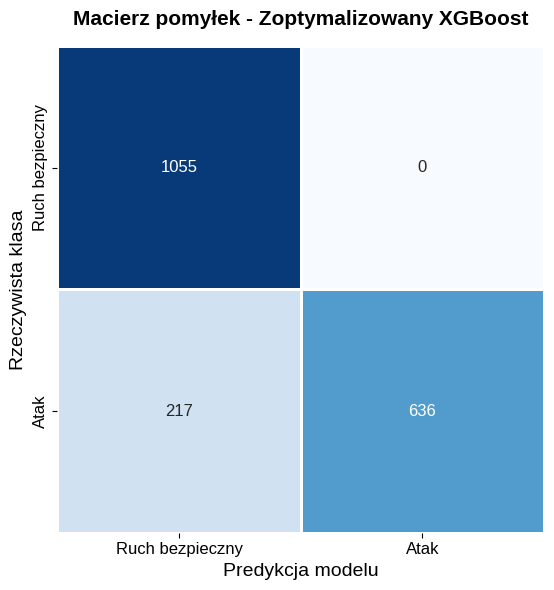

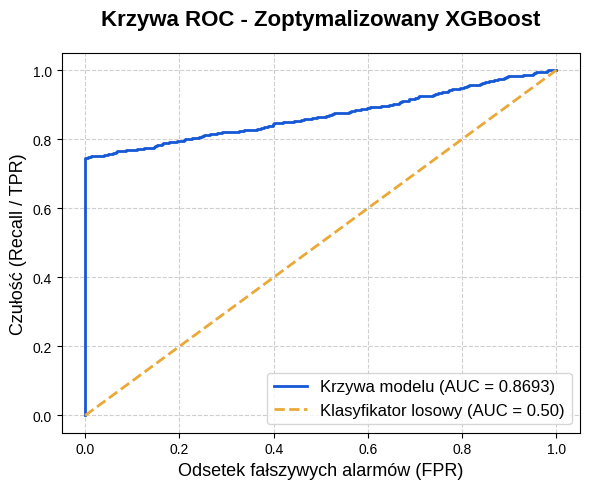

np.float64(0.8692576521115883)

In [7]:
# ============================================================
# 2.1. Implementacja i trenowanie modelu XGBoost
# (Regularization & Early Stopping)
# ============================================================
X_train_xgb, X_val_xgb, y_train_xgb, y_val_xgb = train_test_split(X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)
stosunek_klas = len(y_train_xgb[y_train_xgb == 0]) / len(y_train_xgb[y_train_xgb == 1])

xgb_model = xgb.XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8, random_state=42, scale_pos_weight=stosunek_klas, eval_metric='logloss', early_stopping_rounds=20)
xgb_model.fit(X_train_xgb, y_train_xgb, eval_set=[(X_val_xgb, y_val_xgb)], verbose=0)

y_pred_xgb = xgb_model.predict(X_test)
y_scores_xgb_opt = xgb_model.predict_proba(X_test)[:, 1]

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm_xgb.ravel()
fpr_xgb = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"FPR: {fpr_xgb:.4f}")
print(classification_report(y_test, y_pred_xgb, digits=3))

zapisz_macierz_pomylek(cm_xgb, 'Macierz pomyłek - Zoptymalizowany XGBoost', 'confusion_matrix_xgboost_opt.png')
zapisz_raport_klasyfikacji(y_test, y_pred_xgb, 'raport_xgboost_opt.xlsx')
zapisz_krzywa_roc(y_test, y_scores_xgb_opt, 'Krzywa ROC - Zoptymalizowany XGBoost', 'roc_xgboost_opt.png')

Accuracy: 0.8606
FPR: 0.0559
              precision    recall  f1-score   support

           0      0.828     0.944     0.882      1055
           1      0.916     0.757     0.829       853

    accuracy                          0.861      1908
   macro avg      0.872     0.851     0.856      1908
weighted avg      0.867     0.861     0.859      1908



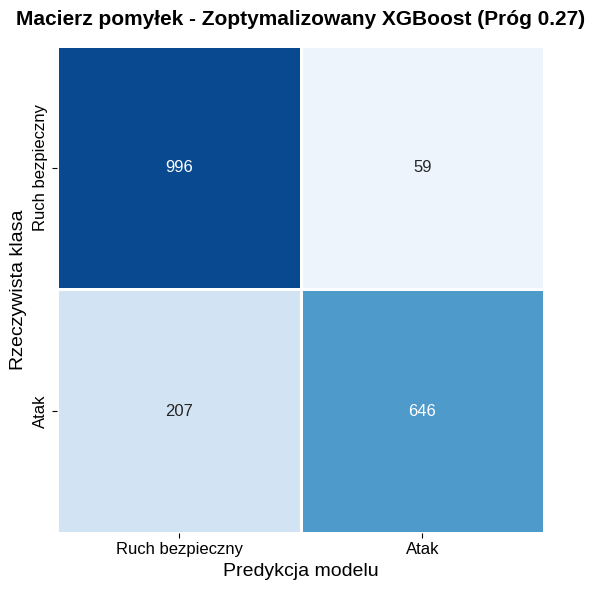

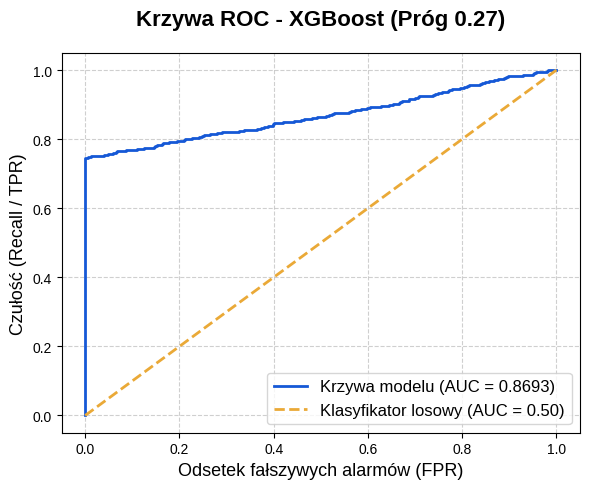

np.float64(0.8692576521115883)

In [8]:
# ============================================================
# 2.2. Implementacja i trenowanie modelu XGBoost
# (Threshold Moving)
# ============================================================
X_train_xgb, X_val_xgb, y_train_xgb, y_val_xgb = train_test_split(X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)
stosunek_klas = len(y_train_xgb[y_train_xgb == 0]) / len(y_train_xgb[y_train_xgb == 1])

xgb_model = xgb.XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8, random_state=42, scale_pos_weight=stosunek_klas, eval_metric='logloss', early_stopping_rounds=20)
xgb_model.fit(X_train_xgb, y_train_xgb, eval_set=[(X_val_xgb, y_val_xgb)], verbose=0)

prawdopodobienstwa_val = xgb_model.predict_proba(X_val_xgb)[:, 1]
maksymalny_akceptowalny_fpr = 0.05
najlepszy_recall = 0.0
znaleziony_prog = 0.50

for prog in np.arange(0.01, 1.0, 0.01):
    y_pred_temp = (prawdopodobienstwa_val >= prog).astype(int)
    cm_temp = confusion_matrix(y_val_xgb, y_pred_temp)
    tn, fp, fn, tp = cm_temp.ravel()
    obecny_fpr = fp / (fp + tn)
    obecny_recall = recall_score(y_val_xgb, y_pred_temp)
    if obecny_fpr <= maksymalny_akceptowalny_fpr and obecny_recall > najlepszy_recall:
        najlepszy_recall = obecny_recall
        znaleziony_prog = prog

prawdopodobienstwa_test = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (prawdopodobienstwa_test >= znaleziony_prog).astype(int)

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm_xgb.ravel()
fpr_xgb = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"FPR: {fpr_xgb:.4f}")
print(classification_report(y_test, y_pred_xgb, digits=3))

zapisz_macierz_pomylek(cm_xgb, f'Macierz pomyłek - Zoptymalizowany XGBoost (Próg {znaleziony_prog:.2f})', 'confusion_matrix_xgboost_opt.png')
zapisz_raport_klasyfikacji(y_test, y_pred_xgb, 'raport_xgboost_opt.xlsx')
zapisz_krzywa_roc(y_test, prawdopodobienstwa_test, f'Krzywa ROC - XGBoost (Próg {znaleziony_prog:.2f})', 'roc_xgboost_opt_threshold.png')

Accuracy: 0.8459
FPR: 0.1014
              precision    recall  f1-score   support

           0      0.835     0.899     0.866      1055
           1      0.862     0.781     0.819       853

    accuracy                          0.846      1908
   macro avg      0.848     0.840     0.842      1908
weighted avg      0.847     0.846     0.845      1908



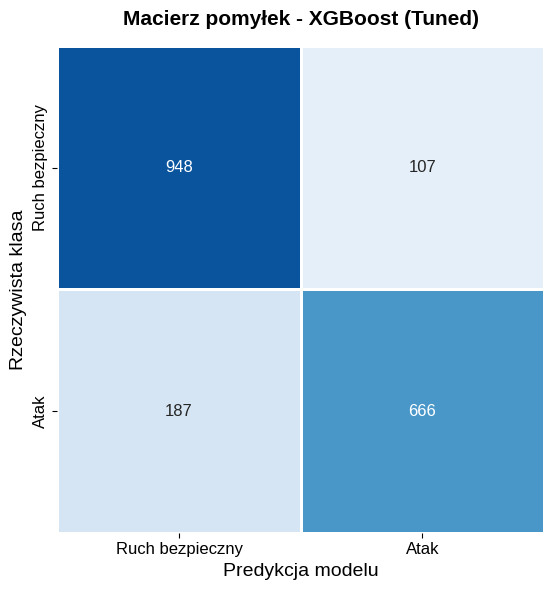

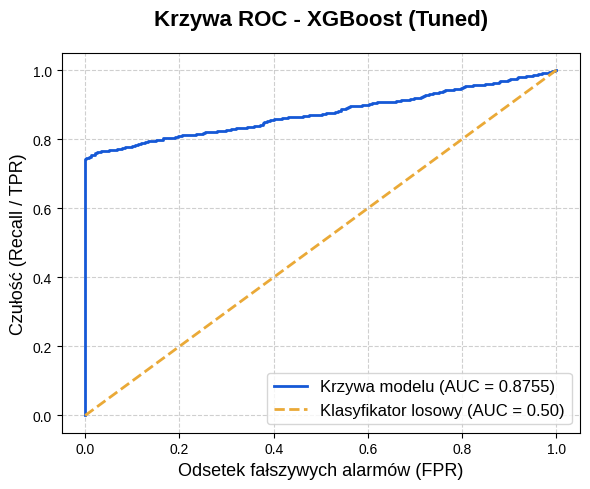

np.float64(0.8754904629881712)

In [9]:
# ============================================================
# 2.3. Implementacja i trenowanie modelu XGBoost
# (Auto-Tuning)
# ============================================================
stosunek_klas = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
param_distributions = {
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 300, 500],
    'scale_pos_weight': [stosunek_klas, stosunek_klas * 1.5, stosunek_klas * 2.5],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3],
    'subsample': [0.7, 0.8, 1.0]
}

xgb_base = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
random_search = RandomizedSearchCV(estimator=xgb_base, param_distributions=param_distributions, n_iter=15, scoring='recall', cv=3, random_state=42, n_jobs=-1, verbose=0)
random_search.fit(X_train, y_train)

xgb_model = random_search.best_estimator_
y_pred_xgb = xgb_model.predict(X_test)
y_scores_xgb_tuned = xgb_model.predict_proba(X_test)[:, 1]

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm_xgb.ravel()
fpr_xgb = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"FPR: {fpr_xgb:.4f}")
print(classification_report(y_test, y_pred_xgb, digits=3))

zapisz_macierz_pomylek(cm_xgb, 'Macierz pomyłek - XGBoost (Tuned)', 'confusion_matrix_xgboost_tuned.png')
zapisz_raport_klasyfikacji(y_test, y_pred_xgb, 'raport_xgboost_tuned.xlsx')
zapisz_krzywa_roc(y_test, y_scores_xgb_tuned, 'Krzywa ROC - XGBoost (Tuned)', 'roc_xgboost_tuned.png')

Accuracy: 0.8816
FPR: 0.0161
              precision    recall  f1-score   support

           0      0.832     0.984     0.902      1055
           1      0.974     0.755     0.851       853

    accuracy                          0.882      1908
   macro avg      0.903     0.869     0.876      1908
weighted avg      0.896     0.882     0.879      1908



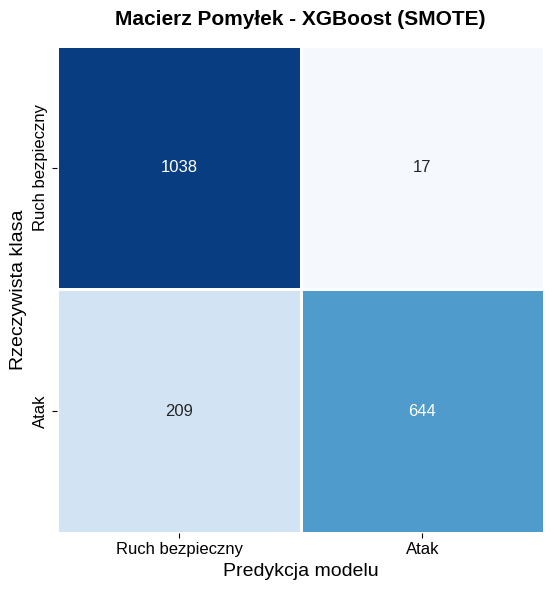

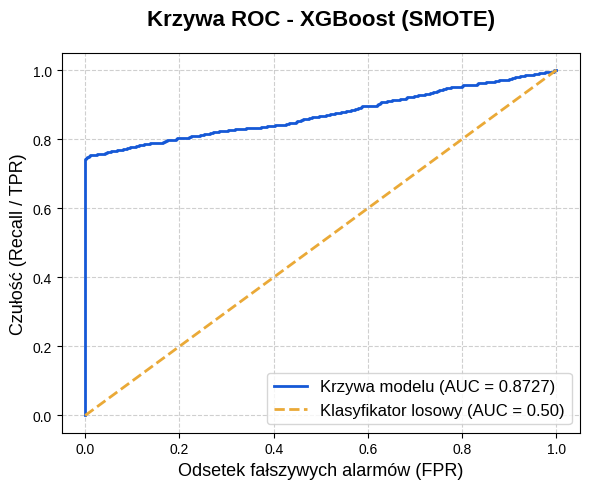

np.float64(0.8727490929698916)

In [10]:
# ============================================================
# 2.4. Implementacja i trenowanie modelu XGBoost
# (SMOTE)
# ============================================================
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

xgb_smote_model = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_smote_model.fit(X_train_smote, y_train_smote, eval_set=[(X_train_smote, y_train_smote), (X_test, y_test)], verbose=0)

y_pred_xgb_smote = xgb_smote_model.predict(X_test)
y_scores_xgb_smote = xgb_smote_model.predict_proba(X_test)[:, 1]

cm_xgb_smote = confusion_matrix(y_test, y_pred_xgb_smote)
tn, fp, fn, tp = cm_xgb_smote.ravel()
fpr_xgb_smote = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_smote):.4f}")
print(f"FPR: {fpr_xgb_smote:.4f}")
print(classification_report(y_test, y_pred_xgb_smote, digits=3))

zapisz_macierz_pomylek(cm_xgb_smote, 'Macierz Pomyłek - XGBoost (SMOTE)', 'confusion_matrix_xgb_smote.png')
zapisz_raport_klasyfikacji(y_test, y_pred_xgb_smote, 'raport_xgb_smote.xlsx')
zapisz_krzywa_roc(y_test, y_scores_xgb_smote, 'Krzywa ROC - XGBoost (SMOTE)', 'roc_xgboost_smote.png')

Accuracy: 0.8805
FPR: 0.0066
              precision    recall  f1-score   support

           0      0.826     0.993     0.902      1055
           1      0.989     0.741     0.847       853

    accuracy                          0.881      1908
   macro avg      0.907     0.867     0.875      1908
weighted avg      0.899     0.881     0.877      1908



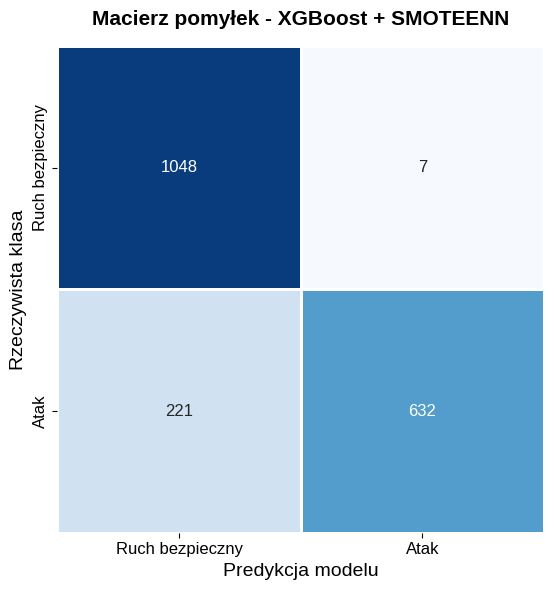

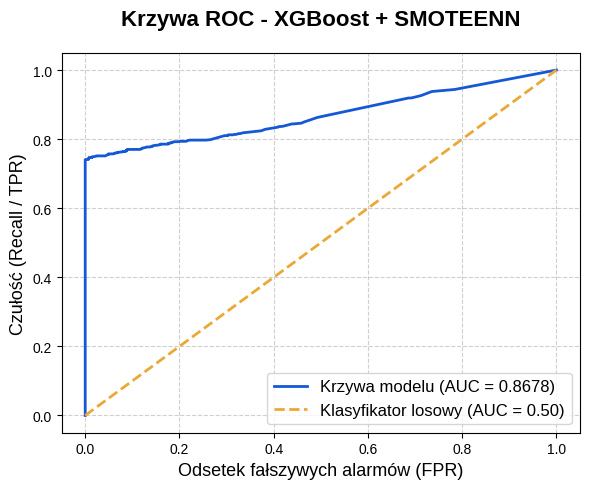

np.float64(0.8677714006322819)

In [11]:
# ============================================================
# 2.5. Implementacja i trenowanie modelu XGBoost
# (SMOTEENN)
# ============================================================
X_train_xgb, X_val_xgb, y_train_xgb, y_val_xgb = train_test_split(X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)

smote_enn = SMOTEENN(random_state=42)
X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train_xgb, y_train_xgb)

xgb_model = xgb.XGBClassifier(n_estimators=300, learning_rate=0.2, max_depth=5, min_child_weight=3, gamma=0, subsample=0.7, random_state=42, eval_metric='aucpr', early_stopping_rounds=20)
xgb_model.fit(X_train_resampled, y_train_resampled, eval_set=[(X_val_xgb, y_val_xgb)], verbose=False)

y_pred_xgb = xgb_model.predict(X_test)
y_scores_xgb_smoteenn = xgb_model.predict_proba(X_test)[:, 1]

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm_xgb.ravel()
fpr_xgb = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"FPR: {fpr_xgb:.4f}")
print(classification_report(y_test, y_pred_xgb, digits=3))

zapisz_macierz_pomylek(cm_xgb, 'Macierz pomyłek - XGBoost + SMOTEENN', 'confusion_matrix_xgboost_smoteenn.png')
zapisz_raport_klasyfikacji(y_test, y_pred_xgb, 'raport_xgboost_smoteenn.xlsx')
zapisz_krzywa_roc(y_test, y_scores_xgb_smoteenn, 'Krzywa ROC - XGBoost + SMOTEENN', 'roc_xgboost_smoteenn.png')

Accuracy: 0.8632
FPR: 0.0493
              precision    recall  f1-score   support

           0      0.828     0.951     0.885      1055
           1      0.925     0.755     0.832       853

    accuracy                          0.863      1908
   macro avg      0.876     0.853     0.858      1908
weighted avg      0.871     0.863     0.861      1908



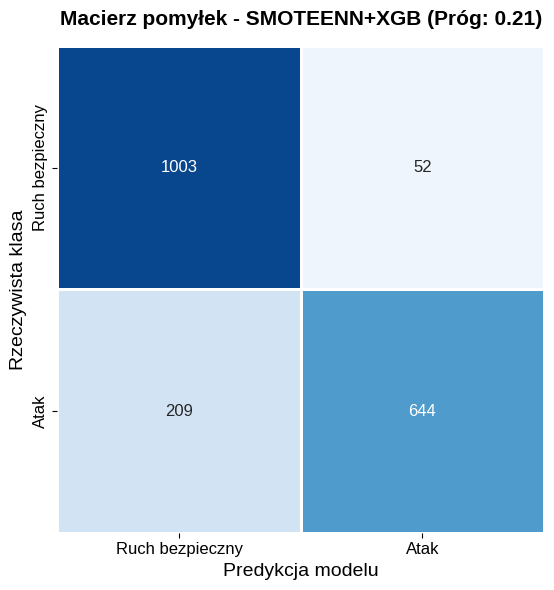

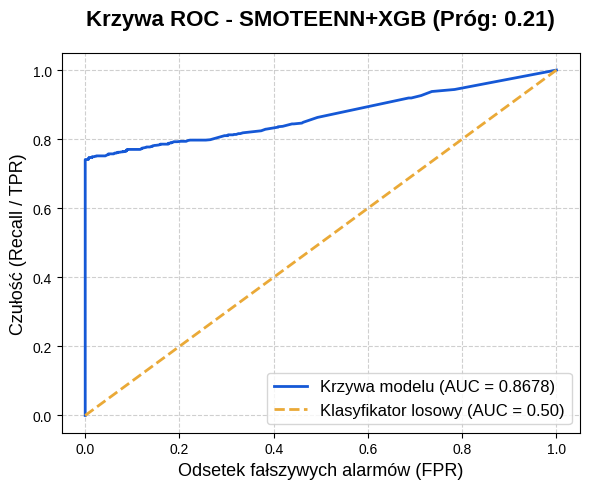

np.float64(0.8677714006322819)

In [12]:
# ============================================================
# 2.5. Implementacja i trenowanie modelu XGBoost
# (SMOTEENN + Dynamic Threshold)
# ============================================================
X_train_xgb, X_val_xgb, y_train_xgb, y_val_xgb = train_test_split(X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)

smote_enn = SMOTEENN(random_state=42)
X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train_xgb, y_train_xgb)

xgb_model = xgb.XGBClassifier(n_estimators=300, learning_rate=0.2, max_depth=5, min_child_weight=3, gamma=0, subsample=0.7, random_state=42, eval_metric='aucpr', early_stopping_rounds=20)
xgb_model.fit(X_train_resampled, y_train_resampled, eval_set=[(X_val_xgb, y_val_xgb)], verbose=False)

prawdopodobienstwa_val = xgb_model.predict_proba(X_val_xgb)[:, 1]
maksymalny_akceptowalny_fpr = 0.05
najlepszy_recall = 0.0
znaleziony_prog = 0.50

for prog in np.arange(0.01, 1.0, 0.01):
    y_pred_temp = (prawdopodobienstwa_val >= prog).astype(int)
    cm_temp = confusion_matrix(y_val_xgb, y_pred_temp)
    tn, fp, fn, tp = cm_temp.ravel()
    obecny_fpr = fp / (fp + tn)
    obecny_recall = recall_score(y_val_xgb, y_pred_temp)
    if obecny_fpr <= maksymalny_akceptowalny_fpr and obecny_recall > najlepszy_recall:
        najlepszy_recall = obecny_recall
        znaleziony_prog = prog

prawdopodobienstwa_test = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb_final = (prawdopodobienstwa_test >= znaleziony_prog).astype(int)

cm_xgb_final = confusion_matrix(y_test, y_pred_xgb_final)
tn, fp, fn, tp = cm_xgb_final.ravel()
fpr_xgb_final = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_final):.4f}")
print(f"FPR: {fpr_xgb_final:.4f}")
print(classification_report(y_test, y_pred_xgb_final, digits=3))

zapisz_macierz_pomylek(cm_xgb_final, f'Macierz pomyłek - SMOTEENN+XGB (Próg: {znaleziony_prog:.2f})', 'confusion_matrix_xgboost_hybrid.png')
zapisz_raport_klasyfikacji(y_test, y_pred_xgb_final, 'raport_xgboost_hybrid.xlsx')
zapisz_krzywa_roc(y_test, prawdopodobienstwa_test, f'Krzywa ROC - SMOTEENN+XGB (Próg: {znaleziony_prog:.2f})', 'roc_xgboost_hybrid.png')

Accuracy: 0.8548
FPR: 0.0616
              precision    recall  f1-score   support

           0      0.824     0.938     0.877      1055
           1      0.908     0.751     0.822       853

    accuracy                          0.855      1908
   macro avg      0.866     0.845     0.850      1908
weighted avg      0.861     0.855     0.853      1908



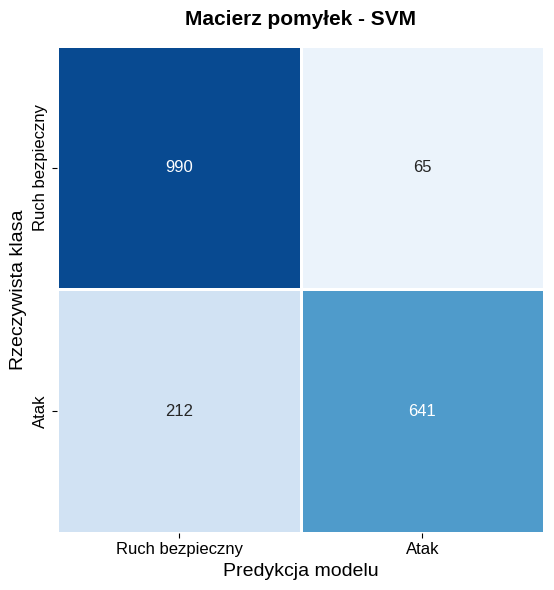

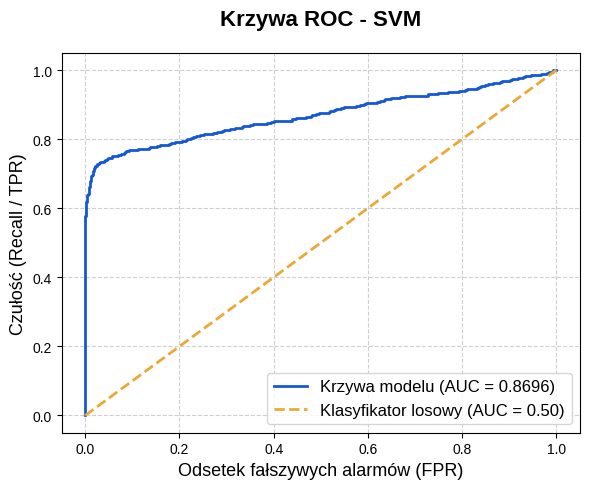

np.float64(0.8695699038242501)

In [13]:
# ============================================================
# 3. Implementacja i trenowanie modelu SVM
# (RBF)
# ============================================================
svm_model = SVC(kernel='rbf', random_state=42, class_weight='balanced')
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
cm_svm = confusion_matrix(y_test, y_pred_svm)
tn, fp, fn, tp = cm_svm.ravel()
fpr_svm = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"FPR: {fpr_svm:.4f}")
print(classification_report(y_test, y_pred_svm, digits=3))

zapisz_macierz_pomylek(cm_svm, 'Macierz pomyłek - SVM', 'confusion_matrix_svm.png')
zapisz_raport_klasyfikacji(y_test, y_pred_svm, 'raport_svm.xlsx')
y_scores_svm = svm_model.decision_function(X_test)
zapisz_krzywa_roc(y_test, y_scores_svm, 'Krzywa ROC - SVM', 'roc_svm.png')

Accuracy: 0.8585
FPR: 0.0474
              precision    recall  f1-score   support

           0      0.820     0.953     0.882      1055
           1      0.927     0.742     0.824       853

    accuracy                          0.858      1908
   macro avg      0.874     0.847     0.853      1908
weighted avg      0.868     0.858     0.856      1908



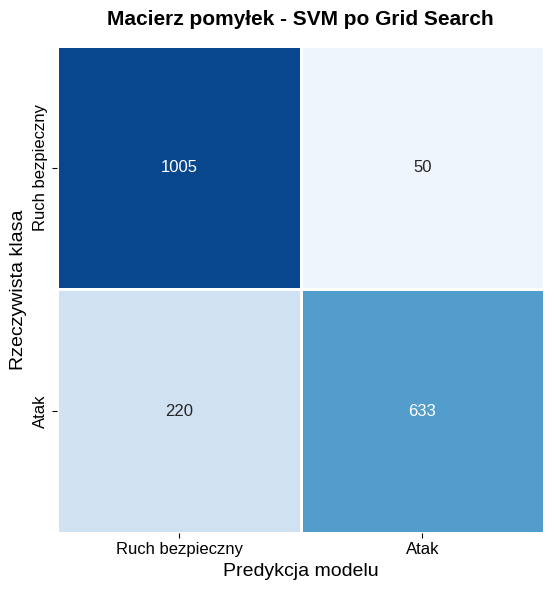

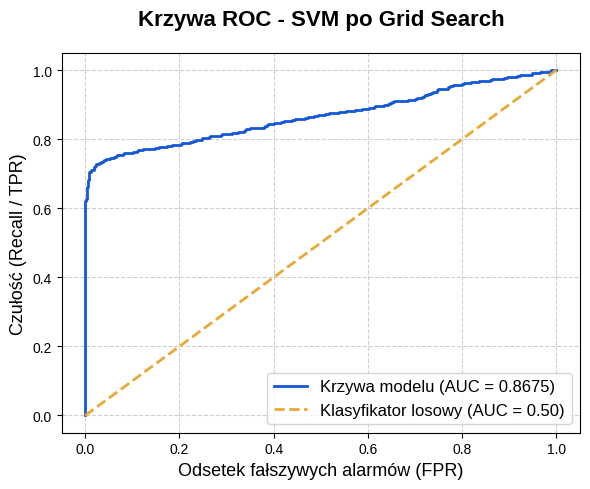

np.float64(0.8674919297933693)

In [14]:
# ============================================================
# 3.1. Implementacja i trenowanie modelu SVM
# (Grid Search)
# ============================================================
param_grid = {'C': [0.1, 1, 10, 50, 100, 500], 'gamma': ['scale', 0.1, 1], 'kernel': ['rbf']}
base_svm = SVC(class_weight='balanced', random_state=42)
grid_search = GridSearchCV(estimator=base_svm, param_grid=param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)

best_svm_model = grid_search.best_estimator_
y_pred_grid_svm = best_svm_model.predict(X_test)
cm_grid_svm = confusion_matrix(y_test, y_pred_grid_svm)
tn, fp, fn, tp = cm_grid_svm.ravel()
fpr_grid_svm = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_grid_svm):.4f}")
print(f"FPR: {fpr_grid_svm:.4f}")
print(classification_report(y_test, y_pred_grid_svm, digits=3))

zapisz_macierz_pomylek(cm_grid_svm, 'Macierz pomyłek - SVM po Grid Search', 'confusion_matrix_grid_svm.png')
zapisz_raport_klasyfikacji(y_test, y_pred_grid_svm, 'raport_grid_svm.xlsx')
y_scores_grid_svm = best_svm_model.decision_function(X_test)
zapisz_krzywa_roc(y_test, y_scores_grid_svm, 'Krzywa ROC - SVM po Grid Search', 'roc_grid_svm.png')

Accuracy: 0.7170
FPR: 0.2701
              precision    recall  f1-score   support

           0      0.751     0.730     0.740      1055
           1      0.677     0.701     0.689       853

    accuracy                          0.717      1908
   macro avg      0.714     0.715     0.715      1908
weighted avg      0.718     0.717     0.717      1908



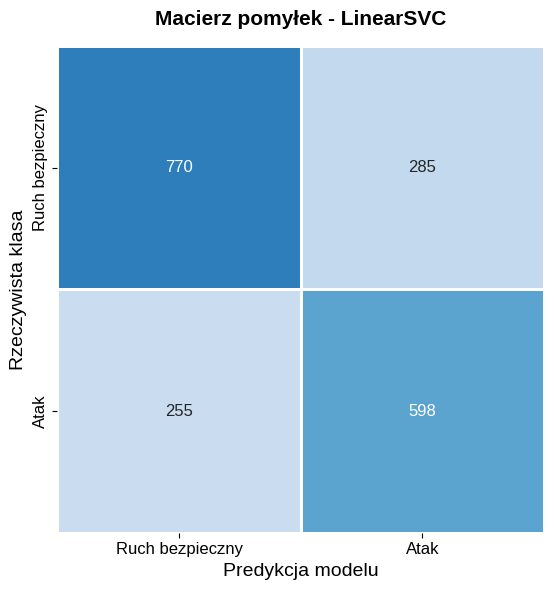

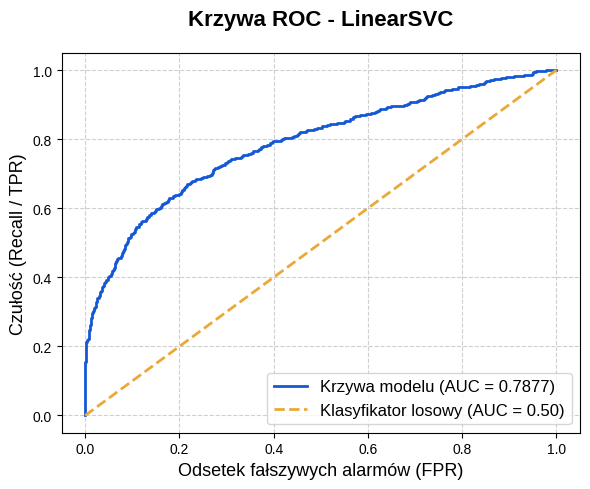

np.float64(0.7876699466060684)

In [15]:
# ============================================================
# 3.2. Implementacja i trenowanie modelu SVM
# (LinearSVC)
# ============================================================
svm_linear_model = LinearSVC(random_state=42, class_weight='balanced', max_iter=2000)
svm_linear_model.fit(X_train, y_train)

y_pred_linear = svm_linear_model.predict(X_test)
y_scores_linear = svm_linear_model.decision_function(X_test)

cm_linear = confusion_matrix(y_test, y_pred_linear)
tn, fp, fn, tp = cm_linear.ravel()
fpr_linear = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_linear):.4f}")
print(f"FPR: {fpr_linear:.4f}")
print(classification_report(y_test, y_pred_linear, digits=3))

zapisz_macierz_pomylek(cm_linear, 'Macierz pomyłek - LinearSVC', 'confusion_matrix_linearsvc.png')
zapisz_raport_klasyfikacji(y_test, y_pred_linear, 'raport_linearsvc.xlsx')
zapisz_krzywa_roc(y_test, y_scores_linear, 'Krzywa ROC - LinearSVC', 'roc_linearsvc.png')

Accuracy: 0.7987
FPR: 0.1754
              precision    recall  f1-score   support

           0      0.814     0.825     0.819      1055
           1      0.779     0.767     0.773       853

    accuracy                          0.799      1908
   macro avg      0.797     0.796     0.796      1908
weighted avg      0.798     0.799     0.799      1908



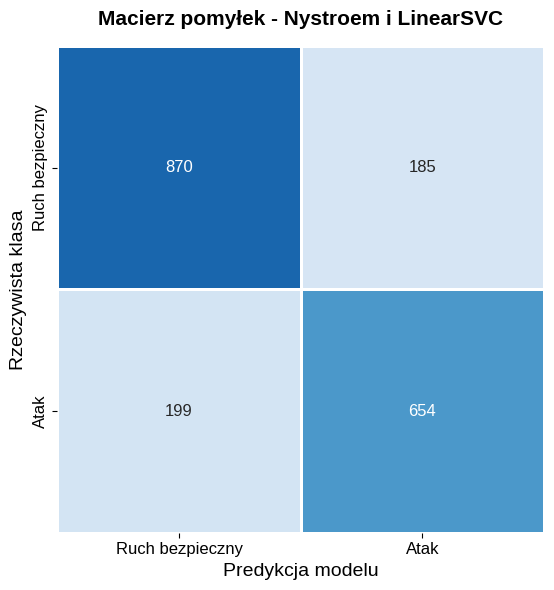

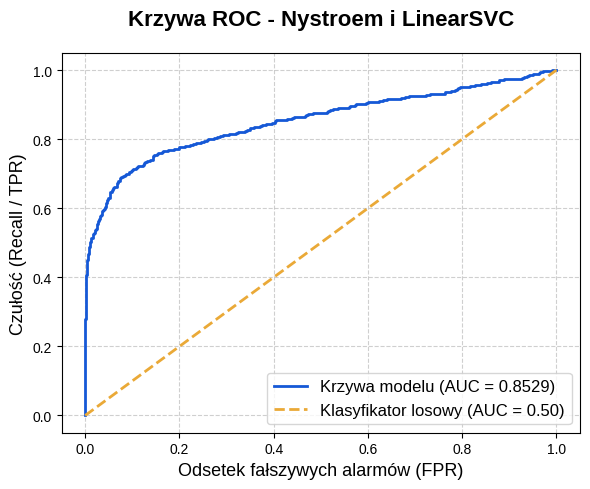

np.float64(0.8529038853669514)

In [16]:
# ============================================================
# 3.3. Implementacja i trenowanie modelu SVM
# (Nystroem + LinearSVC)
# ============================================================
svm_nystroem_model = make_pipeline(Nystroem(gamma=0.2, random_state=42, n_components=300), LinearSVC(random_state=42, class_weight='balanced', max_iter=2000, dual=False))
svm_nystroem_model.fit(X_train, y_train)

y_pred_nystroem = svm_nystroem_model.predict(X_test)
y_scores_nystroem = svm_nystroem_model.decision_function(X_test)

cm_nystroem = confusion_matrix(y_test, y_pred_nystroem)
tn, fp, fn, tp = cm_nystroem.ravel()
fpr_nystroem = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_nystroem):.4f}")
print(f"FPR: {fpr_nystroem:.4f}")
print(classification_report(y_test, y_pred_nystroem, digits=3))

zapisz_macierz_pomylek(cm_nystroem, 'Macierz pomyłek - Nystroem i LinearSVC', 'confusion_matrix_nystroem_linearsvc.png')
zapisz_raport_klasyfikacji(y_test, y_pred_nystroem, 'raport_nystroem_linearsvc.xlsx')
zapisz_krzywa_roc(y_test, y_scores_nystroem, 'Krzywa ROC - Nystroem i LinearSVC', 'roc_nystroem_linearsvc.png')

Accuracy: 0.7070
FPR: 0.2445
              precision    recall  f1-score   support

           0      0.726     0.755     0.740      1055
           1      0.681     0.647     0.664       853

    accuracy                          0.707      1908
   macro avg      0.704     0.701     0.702      1908
weighted avg      0.706     0.707     0.706      1908



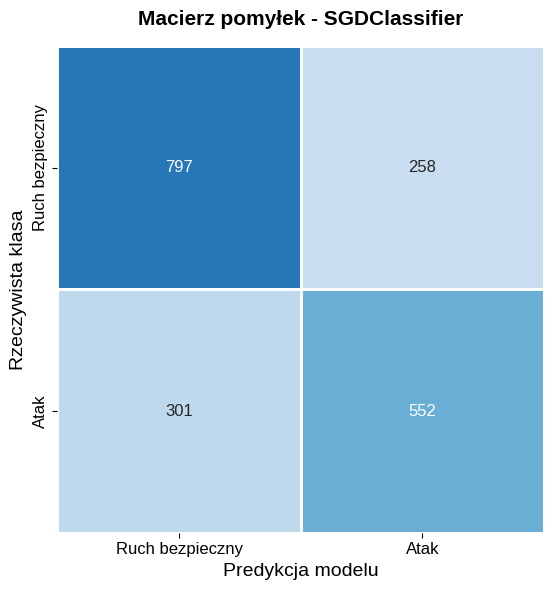

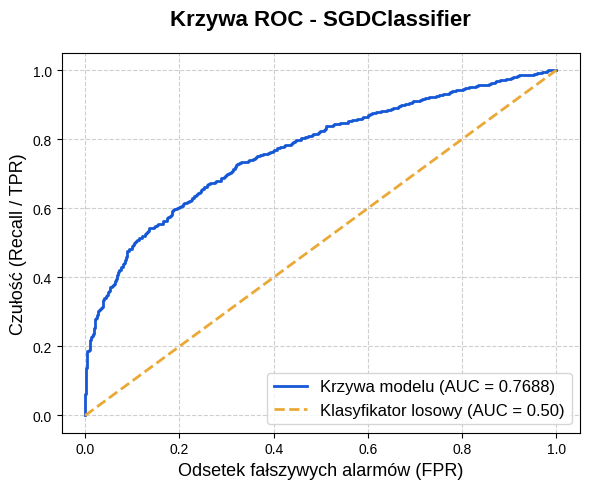

np.float64(0.7687814960301806)

In [17]:
# ============================================================
# 3.4. Implementacja i trenowanie modelu SVM
# (SGDClassifier)
# ============================================================
svm_sgd_model = SGDClassifier(loss='hinge', random_state=42, class_weight='balanced', max_iter=2000)
svm_sgd_model.fit(X_train, y_train)

y_pred_svm_sgd = svm_sgd_model.predict(X_test)
y_scores_svm_sgd = svm_sgd_model.decision_function(X_test)

cm_svm_sgd = confusion_matrix(y_test, y_pred_svm_sgd)
tn, fp, fn, tp = cm_svm_sgd.ravel()
fpr_svm_sgd = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_svm_sgd):.4f}")
print(f"FPR: {fpr_svm_sgd:.4f}")
print(classification_report(y_test, y_pred_svm_sgd, digits=3))

zapisz_macierz_pomylek(cm_svm_sgd, 'Macierz pomyłek - SGDClassifier', 'confusion_matrix_sgdclassifier.png')
zapisz_raport_klasyfikacji(y_test, y_pred_svm_sgd, 'raport_sgdclassifier.xlsx')
zapisz_krzywa_roc(y_test, y_scores_svm_sgd, 'Krzywa ROC - SGDClassifier', 'roc_sgdclassifier.png')

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 0.8816
FPR: 0.0047
              precision    recall  f1-score   support

           0      0.826     0.995     0.903      1055
           1      0.992     0.741     0.848       853

    accuracy                          0.882      1908
   macro avg      0.909     0.868     0.876      1908
weighted avg      0.900     0.882     0.878      1908



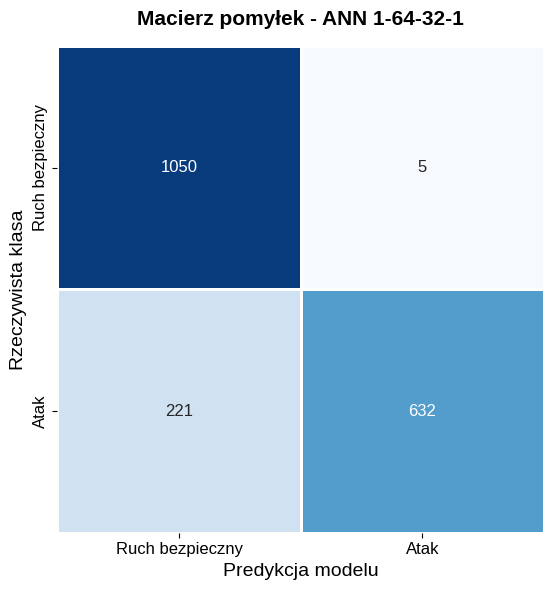

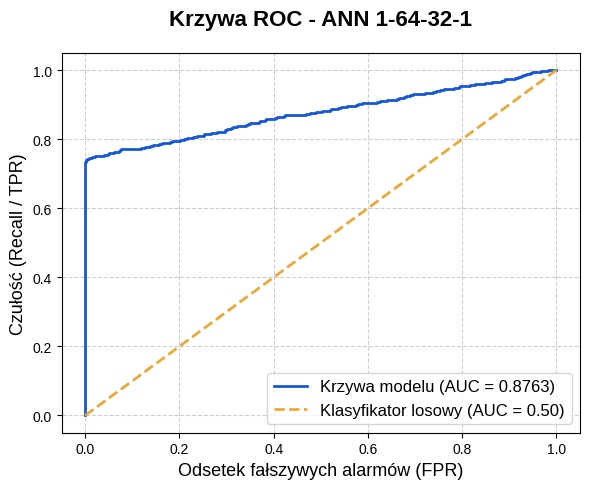

In [18]:
# ============================================================
# 4. Implementacja i trenowanie modelu ANN
# (1-64-32-1)
# ============================================================
ann_model = Sequential()
ann_model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
ann_model.add(Dropout(0.3))
ann_model.add(Dense(32, activation='relu'))
ann_model.add(Dropout(0.2))
ann_model.add(Dense(1, activation='sigmoid'))
ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = ann_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stop], verbose=0)

y_pred_proba_ann = ann_model.predict(X_test, verbose=0)
y_pred_ann = (y_pred_proba_ann > 0.5).astype(int)
y_scores_ann = y_pred_proba_ann.ravel()

cm_ann = confusion_matrix(y_test, y_pred_ann)
tn, fp, fn, tp = cm_ann.ravel()
fpr_ann = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_ann):.4f}")
print(f"FPR: {fpr_ann:.4f}")
print(classification_report(y_test, y_pred_ann, digits=3))

zapisz_macierz_pomylek(cm_ann, 'Macierz pomyłek - ANN 1-64-32-1', 'confusion_matrix_ann.png')
zapisz_raport_klasyfikacji(y_test, y_pred_ann, 'raport_ann.xlsx')
zapisz_krzywa_roc(y_test, y_scores_ann, 'Krzywa ROC - ANN 1-64-32-1', 'roc_ann.png')

plt.figure(figsize=(6, 5))
plt.plot(history.history['loss'], label='Błąd na Treningu', color='#1558d6', linewidth=2)
plt.plot(history.history['val_loss'], label='Błąd na Walidacji', color='#eaa937', linewidth=2)
plt.title('Historia uczenia - ANN 1-64-32-1', fontsize=16, pad=20, weight='bold')
plt.xlabel('Epoka', fontsize=13)
plt.ylabel('Wartość Błędu', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
os.makedirs("/content/drive/MyDrive/Colab Notebooks/cybersec_ml_mgr/learning_curve/", exist_ok=True)
plt.savefig("/content/drive/MyDrive/Colab Notebooks/cybersec_ml_mgr/learning_curve/learning_curve_ann.png", dpi=300, bbox_inches='tight')
plt.close()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 0.8800
FPR: 0.0180
              precision    recall  f1-score   support

           0      0.831     0.982     0.900      1055
           1      0.971     0.754     0.849       853

    accuracy                          0.880      1908
   macro avg      0.901     0.868     0.875      1908
weighted avg      0.894     0.880     0.877      1908



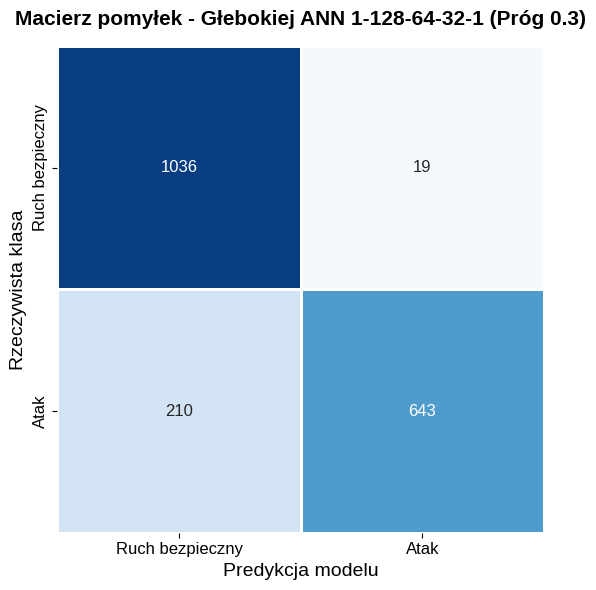

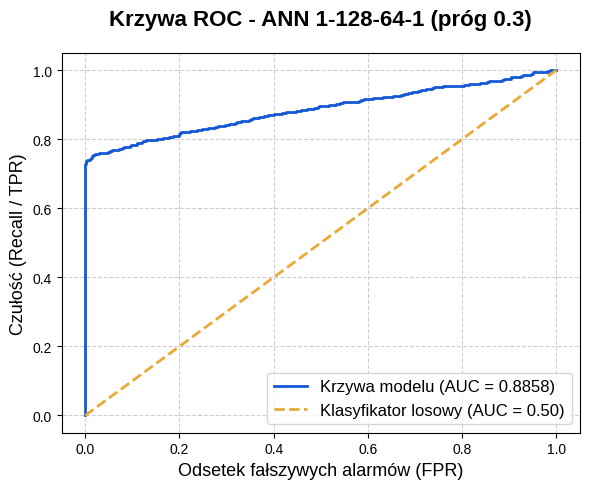

In [19]:
# ============================================================
# 4.1. Implementacja i trenowanie modelu ANN
# (1-128-64-32-1)
# ============================================================
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
weights_dict = {0: class_weights[0], 1: class_weights[1]}

ann_opt_model = Sequential()
ann_opt_model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
ann_opt_model.add(Dropout(0.3))
ann_opt_model.add(Dense(64, activation='relu'))
ann_opt_model.add(Dropout(0.3))
ann_opt_model.add(Dense(32, activation='relu'))
ann_opt_model.add(Dropout(0.2))
ann_opt_model.add(Dense(1, activation='sigmoid'))
ann_opt_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop_opt = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
history_opt = ann_opt_model.fit(X_train, y_train, epochs=150, batch_size=32, validation_split=0.2, class_weight=weights_dict, callbacks=[early_stop_opt], verbose=0)

y_pred_proba_ann_opt = ann_opt_model.predict(X_test, verbose=0)
ann_threshold = 0.30
y_pred_ann_opt = (y_pred_proba_ann_opt > ann_threshold).astype(int)
y_scores_ann_opt = y_pred_proba_ann_opt.ravel()

cm_ann_opt = confusion_matrix(y_test, y_pred_ann_opt)
tn, fp, fn, tp = cm_ann_opt.ravel()
fpr_ann_opt = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_ann_opt):.4f}")
print(f"FPR: {fpr_ann_opt:.4f}")
print(classification_report(y_test, y_pred_ann_opt, digits=3))

zapisz_macierz_pomylek(cm_ann_opt, f'Macierz pomyłek - Głebokiej ANN 1-128-64-32-1 (Próg {ann_threshold})', 'confusion_matrix_deep_ann.png')
zapisz_raport_klasyfikacji(y_test, y_pred_ann_opt, 'raport_deep_ann.xlsx')
zapisz_krzywa_roc(y_test, y_scores_ann_opt, f'Krzywa ROC - ANN 1-128-64-1 (próg {ann_threshold})', 'roc_deep_ann.png')

plt.figure(figsize=(6, 5))
plt.plot(history_opt.history['loss'], label='Błąd na Treningu', color='#1558d6', linewidth=2)
plt.plot(history_opt.history['val_loss'], label='Błąd na Walidacji', color='#eaa937', linewidth=2)
plt.title(f'Historia uczenia - Głębokiej ANN 1-128-64-32-1 (Próg {ann_threshold})', fontsize=16, pad=20, weight='bold')
plt.xlabel('Epoka', fontsize=13)
plt.ylabel('Wartość Błędu', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/cybersec_ml_mgr/learning_curve/learning_curve_deep_ann.png", dpi=300, bbox_inches='tight')
plt.close()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 0.8732
FPR: 0.0256
              precision    recall  f1-score   support

           0      0.827     0.974     0.895      1055
           1      0.959     0.748     0.841       853

    accuracy                          0.873      1908
   macro avg      0.893     0.861     0.868      1908
weighted avg      0.886     0.873     0.870      1908



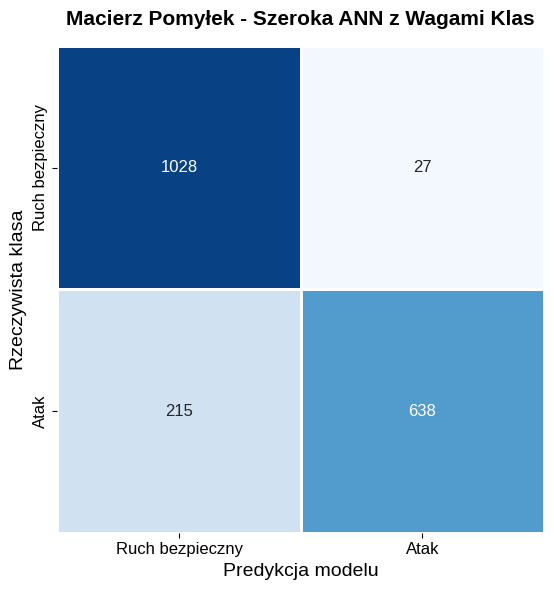

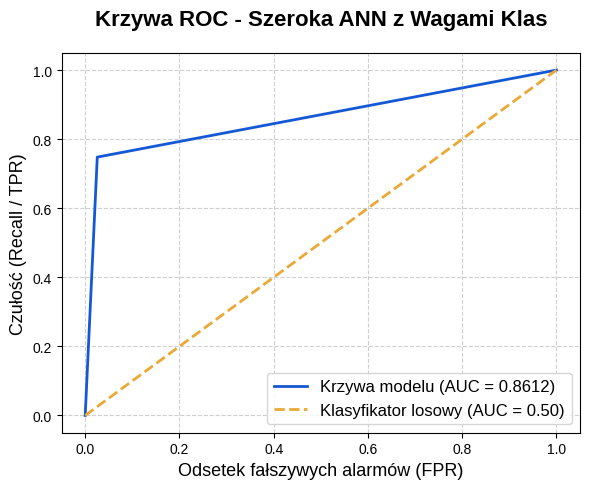

In [20]:
# ============================================================
# 4.2. Implementacja i trenowanie modelu ANN
# (Szeroka sieć, 256-128-64-1, wagi klas)
# ============================================================
X_train_split, X_val, y_train_split, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)
wagi = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_split), y=y_train_split)
class_weight_dict = dict(zip(np.unique(y_train_split), wagi))

ann_wide_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_split.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
ann_wide_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.0001)

history_wide = ann_wide_model.fit(X_train_split, y_train_split, epochs=100, batch_size=64, class_weight=class_weight_dict, validation_data=(X_val, y_val), callbacks=[early_stop, reduce_lr], verbose=0)

y_pred_proba_wide = ann_wide_model.predict(X_test, verbose=0)
y_pred_ann_wide = (y_pred_proba_wide > 0.5).astype(int).ravel()
y_scores_ann_wide = y_pred_ann_wide.ravel()

cm_wide_ann = confusion_matrix(y_test, y_pred_ann_wide)
tn, fp, fn, tp = cm_wide_ann.ravel()
fpr_wide_ann = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_ann_wide):.4f}")
print(f"FPR: {fpr_wide_ann:.4f}")
print(classification_report(y_test, y_pred_ann_wide, digits=3))

zapisz_macierz_pomylek(cm_wide_ann, 'Macierz Pomyłek - Szeroka ANN z Wagami Klas', 'confusion_matrix_wide_ann_classweights.png')
zapisz_raport_klasyfikacji(y_test, y_pred_ann_wide, 'raport_wide_ann_classweights.xlsx')
zapisz_krzywa_roc(y_test, y_scores_ann_wide, 'Krzywa ROC - Szeroka ANN z Wagami Klas', 'roc_wide_ann_classweights.png')

plt.figure(figsize=(6, 5))
plt.plot(history_wide.history['loss'], label='Błąd na Treningu', color='#1558d6', linewidth=2)
plt.plot(history_wide.history['val_loss'], label='Błąd na Walidacji', color='#eaa937', linewidth=2)
plt.title('Historia uczenia - Szeroka ANN z Wagami Klas', fontsize=16, pad=20, weight='bold')
plt.xlabel('Epoka', fontsize=13)
plt.ylabel('Wartość Błędu', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/cybersec_ml_mgr/learning_curve/learning_curve_wide_ann_classweights.png", dpi=300, bbox_inches='tight')
plt.close()